In [ ]:
import zipfile

zip_path = "/content/CREMA-D.zip"
extract_path = "/content/CREMAD"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [ ]:
import os

print(os.listdir("/content/CREMAD"))

['AudioWAV']


In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
DATASET_PATH = "/content/CREMAD"

wav_files = list(Path(DATASET_PATH).rglob("*.wav"))

print("Total audio files:", len(wav_files))
print("Example file:", wav_files[0])

Total audio files: 7442
Example file: /content/CREMAD/AudioWAV/1046_DFA_HAP_XX.wav


In [ ]:
emotion_map = {
    "ANG": "Angry",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad"
}

records = []

for file in wav_files:

    filename = Path(file).stem

    parts = filename.split("_")

    speaker = parts[0]
    emotion_code = parts[2]

    records.append({
        "file": str(file),
        "speaker": speaker,
        "emotion": emotion_map[emotion_code]
    })

df = pd.DataFrame(records)

df.head()

,file,speaker,emotion
0,/content/CREMAD/AudioWAV/1046_DFA_HAP_XX.wav,1046,Happy
1,/content/CREMAD/AudioWAV/1080_IOM_DIS_XX.wav,1080,Disgust
2,/content/CREMAD/AudioWAV/1065_IWW_FEA_XX.wav,1065,Fear
3,/content/CREMAD/AudioWAV/1086_TIE_FEA_XX.wav,1086,Fear
4,/content/CREMAD/AudioWAV/1013_TSI_HAP_XX.wav,1013,Happy


In [ ]:
print("Total Files:", len(df))
print("Unique Speakers:", df["speaker"].nunique())
print("Emotion Classes:", df["emotion"].nunique())

print("\nEmotion Categories:")
print(df["emotion"].unique())

Total Files: 7442
Unique Speakers: 91
Emotion Classes: 6

Emotion Categories:
['Happy' 'Disgust' 'Fear' 'Neutral' 'Angry' 'Sad']


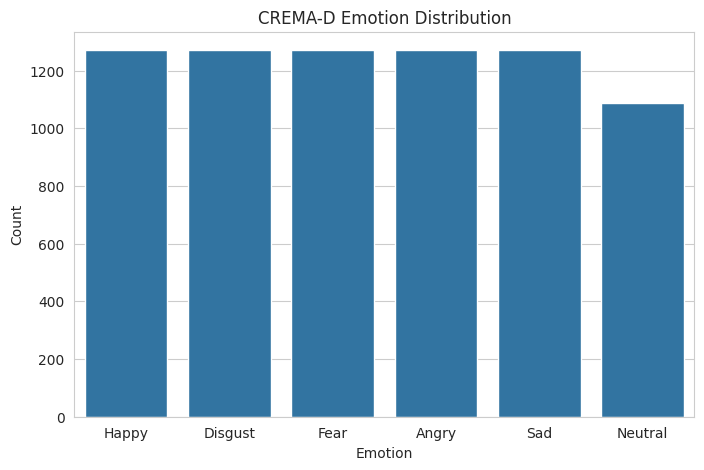

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="emotion",
    order=df["emotion"].value_counts().index
)

plt.title("CREMA-D Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")

plt.show()

In [ ]:
plt.savefig("cremad_emotion_distribution.png")

<Figure size 640x480 with 0 Axes>

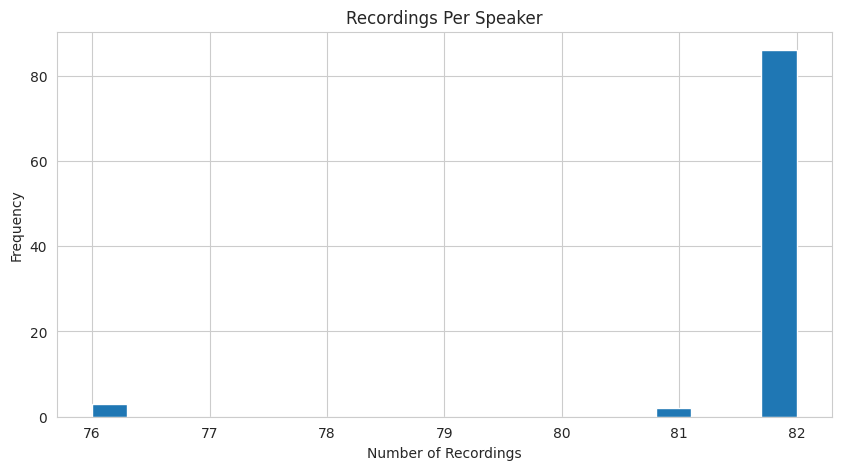

In [ ]:
speaker_counts = df["speaker"].value_counts()

plt.figure(figsize=(10,5))

speaker_counts.hist(bins=20)

plt.title("Recordings Per Speaker")
plt.xlabel("Number of Recordings")
plt.ylabel("Frequency")

plt.show()

In [ ]:
durations = []

for file in df["file"]:

    duration = librosa.get_duration(path=file)

    durations.append(duration)

df["duration"] = durations

In [ ]:
df["duration"].describe()

,duration
count,7442.000000
mean,2.542884
std,0.505979
min,1.267937
25%,2.202187
50%,2.502500
75%,2.836187
max,5.005000


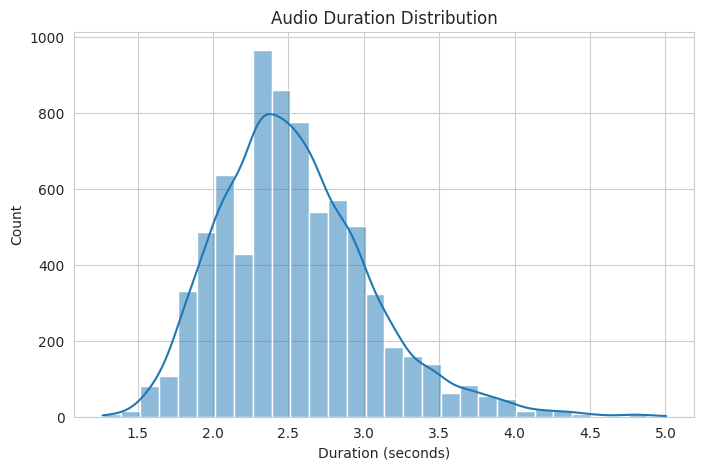

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["duration"],
    bins=30,
    kde=True
)

plt.title("Audio Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")

plt.show()

In [ ]:
corrupted = 0

for file in df["file"]:

    try:
        y, sr = librosa.load(file, sr=None)

    except Exception:
        corrupted += 1

print("Corrupted Files:", corrupted)

Corrupted Files: 0


In [ ]:
samples = {}

for emotion in ["Angry", "Happy", "Sad"]:

    sample = df[df["emotion"] == emotion]["file"].iloc[0]

    samples[emotion] = sample

samples

{'Angry': '/content/CREMAD/AudioWAV/1035_IOM_ANG_XX.wav',
 'Happy': '/content/CREMAD/AudioWAV/1046_DFA_HAP_XX.wav',
 'Sad': '/content/CREMAD/AudioWAV/1020_TAI_SAD_XX.wav'}

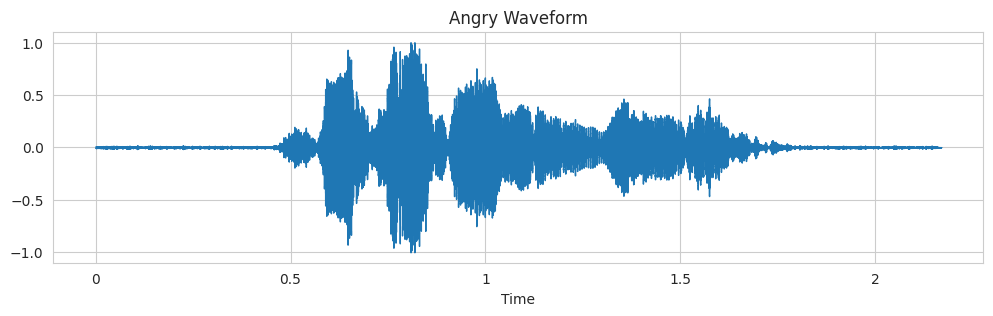

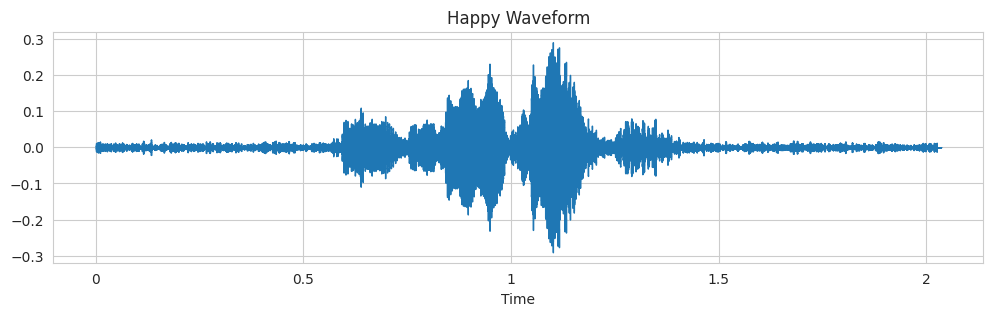

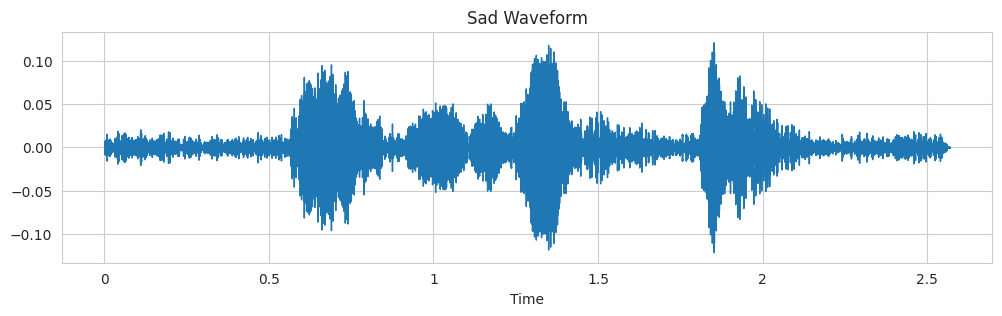

In [ ]:
for emotion, file in samples.items():

    y, sr = librosa.load(file)

    plt.figure(figsize=(12,3))

    librosa.display.waveshow(y, sr=sr)

    plt.title(f"{emotion} Waveform")

    plt.show()

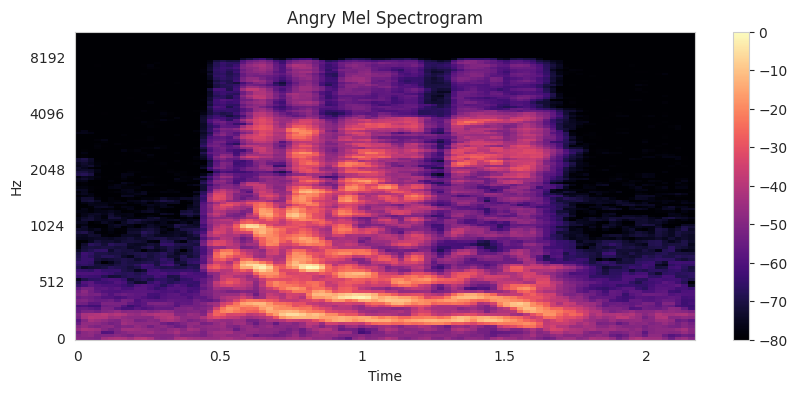

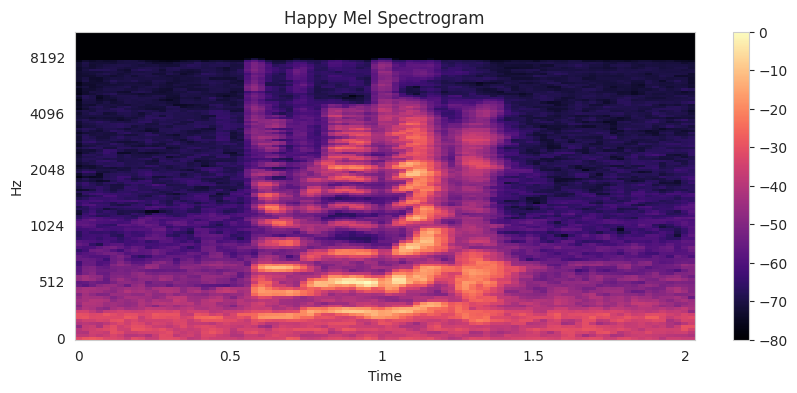

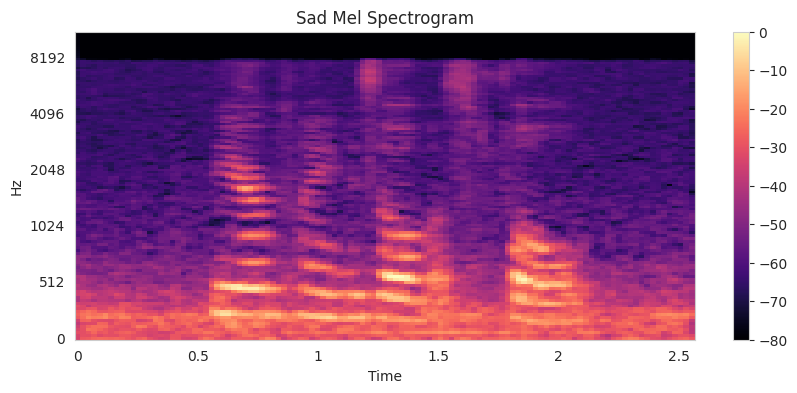

In [ ]:
for emotion, file in samples.items():

    y, sr = librosa.load(file)

    mel = librosa.feature.melspectrogram(y=y, sr=sr)

    mel_db = librosa.power_to_db(mel, ref=np.max)

    plt.figure(figsize=(10,4))

    librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis="time",
        y_axis="mel"
    )

    plt.colorbar()

    plt.title(f"{emotion} Mel Spectrogram")

    plt.show()

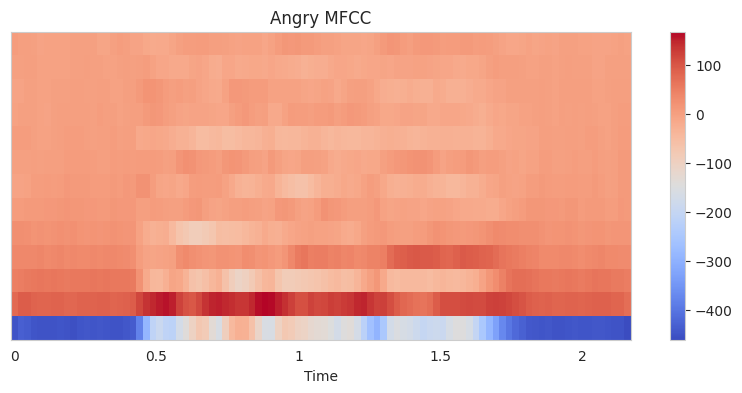

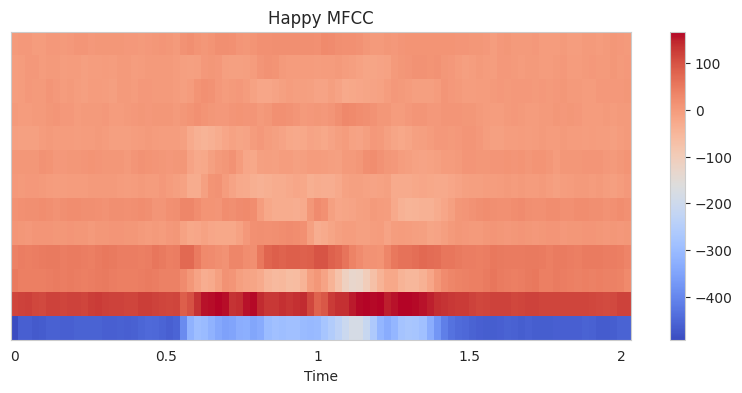

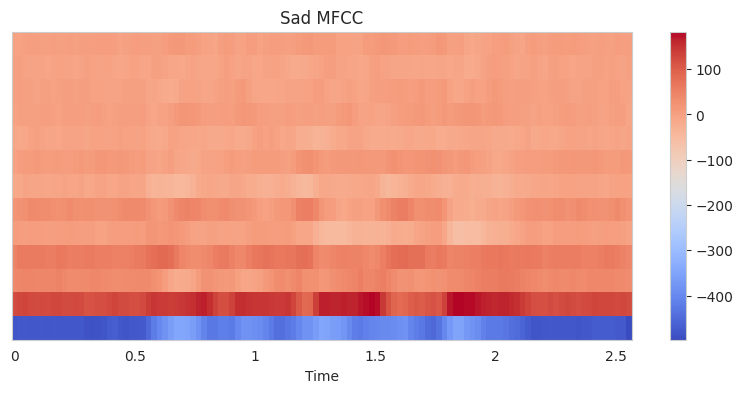

In [ ]:
for emotion, file in samples.items():

    y, sr = librosa.load(file)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    plt.figure(figsize=(10,4))

    librosa.display.specshow(
        mfcc,
        x_axis="time"
    )

    plt.colorbar()

    plt.title(f"{emotion} MFCC")

    plt.show()

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Total Files",
        "Speakers",
        "Emotion Classes",
        "Average Duration",
        "Corrupted Files"
    ],
    "Value": [
        len(df),
        df["speaker"].nunique(),
        df["emotion"].nunique(),
        round(df["duration"].mean(), 2),
        corrupted
    ]
})

summary

,Metric,Value
0,Total Files,7442.00
1,Speakers,91.00
2,Emotion Classes,6.00
3,Average Duration,2.54
4,Corrupted Files,0.00


In [ ]:
feature_data = []

In [ ]:
import numpy as np
import librosa
from tqdm import tqdm

feature_data = []

for file in tqdm(df['file']):

    y, sr = librosa.load(file, sr=None)

    mfccs = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13
    )

    chroma = librosa.feature.chroma_stft(
        y=y,
        sr=sr
    )

    rms = librosa.feature.rms(y=y)

    zcr = librosa.feature.zero_crossing_rate(y)

    feature_data.append({
        "mfcc_mean": np.mean(mfccs),
        "mfcc_std": np.std(mfccs),
        "chroma_mean": np.mean(chroma),
        "rms_mean": np.mean(rms),
        "zcr_mean": np.mean(zcr)
    })

features_df = pd.DataFrame(feature_data)

features_df.head()

 60%|██████    | 4491/7442 [01:59<01:02, 47.32it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
100%|██████████| 7442/7442 [03:15<00:00, 38.01it/s]


,mfcc_mean,mfcc_std,chroma_mean,rms_mean,zcr_mean
0,-14.982108,108.370827,0.385225,0.021953,0.067131
1,-15.382116,112.301132,0.375670,0.014484,0.059636
2,-15.197864,108.773117,0.429623,0.014133,0.062789
3,-15.301764,103.748474,0.374551,0.039913,0.091379
4,-14.420280,95.992531,0.327677,0.038087,0.164090


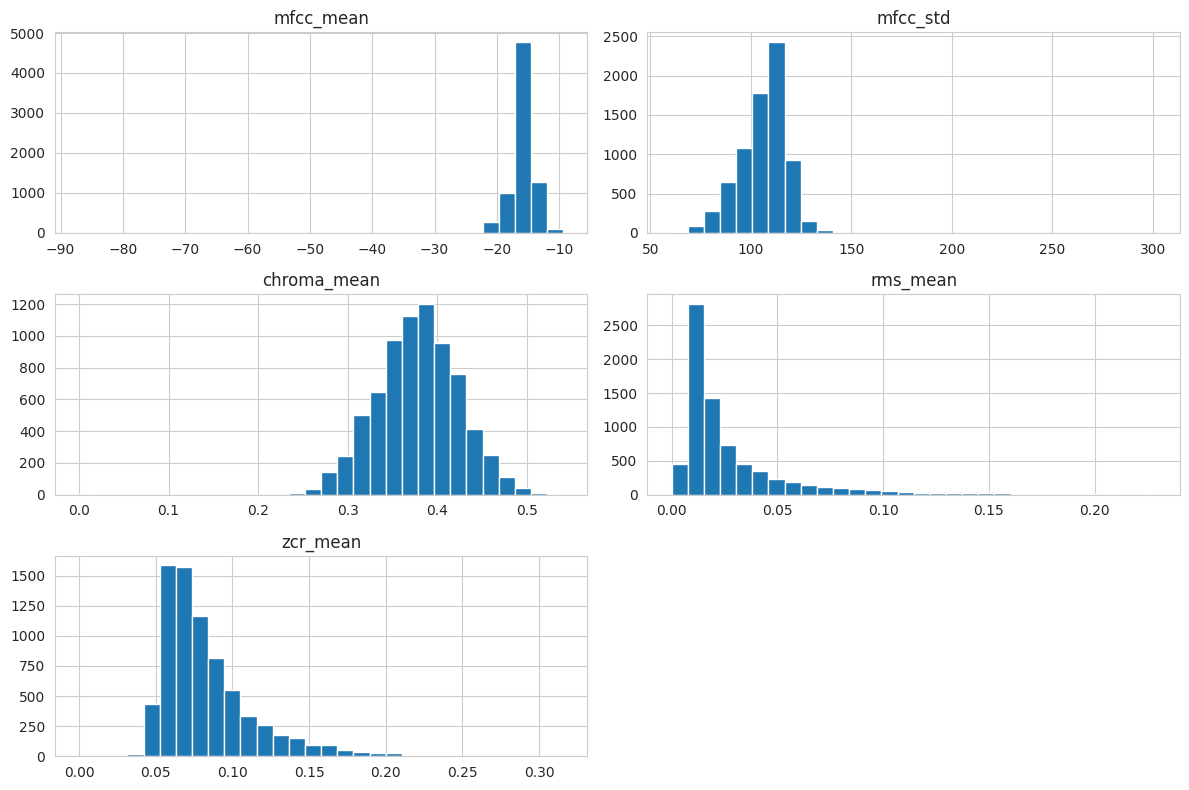

In [ ]:
features_df.hist(
    figsize=(12,8),
    bins=30
)

plt.tight_layout()
plt.show()

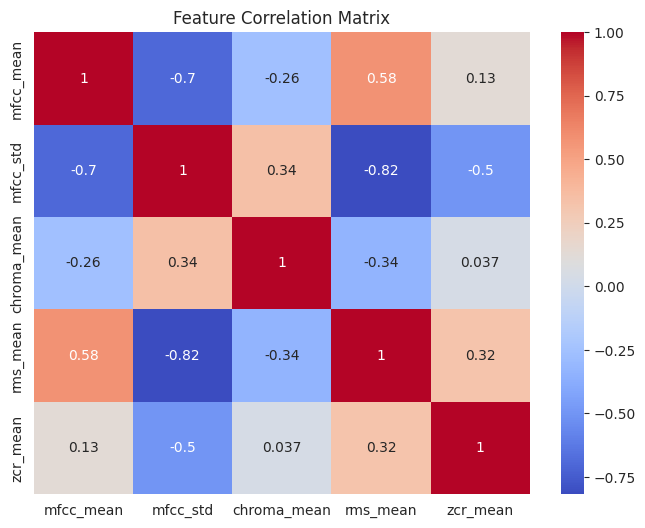

In [ ]:
corr = features_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")

plt.show()

In [ ]:
eda_df = pd.concat(
    [df.reset_index(drop=True),
     features_df.reset_index(drop=True)],
    axis=1
)

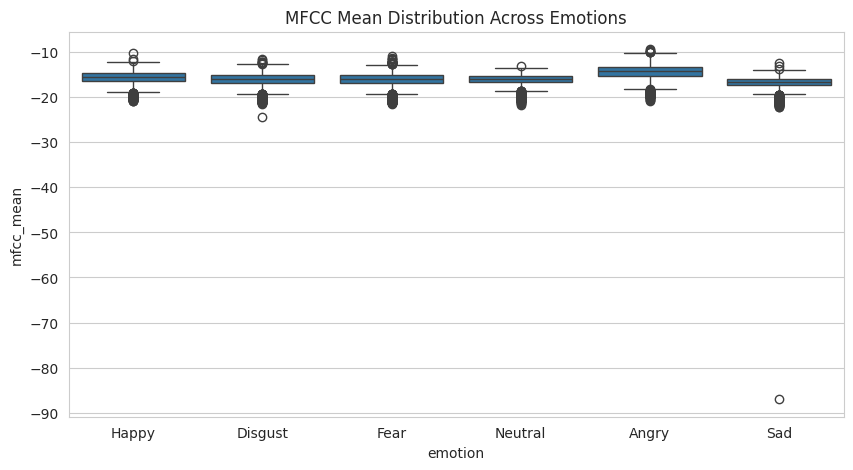

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=eda_df,
    x='emotion',
    y='mfcc_mean'
)

plt.title("MFCC Mean Distribution Across Emotions")

plt.show()

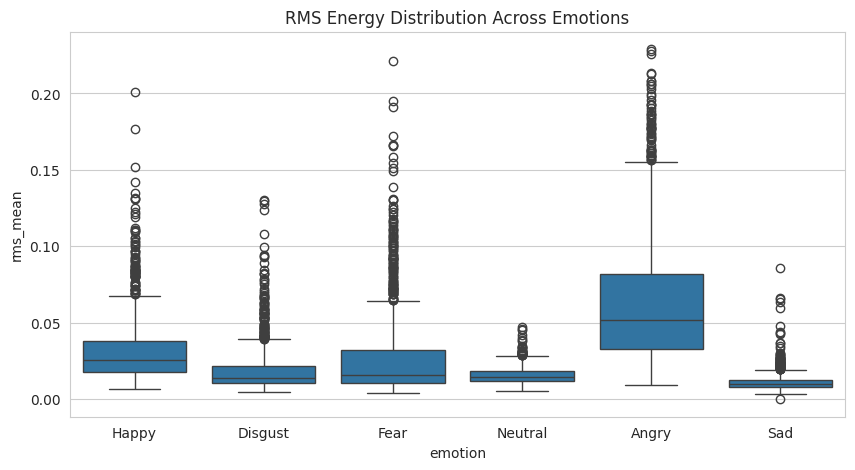

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=eda_df,
    x='emotion',
    y='rms_mean'
)

plt.title("RMS Energy Distribution Across Emotions")

plt.show()

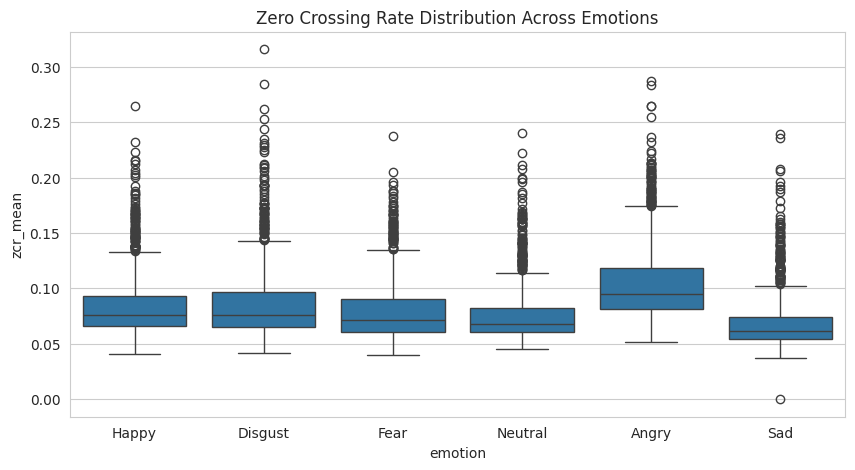

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=eda_df,
    x='emotion',
    y='zcr_mean'
)

plt.title("Zero Crossing Rate Distribution Across Emotions")

plt.show()

In [ ]:
print(df.columns)

Index(['file', 'speaker', 'emotion', 'duration'], dtype='object')


In [ ]:
print(df.columns.tolist())

['file', 'speaker', 'emotion', 'duration']


In [ ]:
print("\n[3] Plotting gender distribution...")

# CREMA-D speaker IDs
male_ids = {
    '1001','1002','1003','1004','1005','1006','1007','1008','1009','1010',
    '1011','1012','1013','1014','1015','1016','1017','1018','1019','1020',
    '1022','1023','1025','1026','1027','1028','1029','1030','1031','1032',
    '1033','1034','1035','1036','1037','1038','1039','1040','1041','1043',
    '1044','1045','1046','1047','1048'
}

df["gender"] = df["speaker"].astype(str).apply(
    lambda x: "Male" if x in male_ids else "Female"
)


[3] Plotting gender distribution...


In [ ]:
print(df["gender"].value_counts())

gender
Female    3771
Male      3671
Name: count, dtype: int64


In [ ]:
print(df["speaker"].unique()[:20])

['1046' '1080' '1065' '1086' '1013' '1035' '1040' '1020' '1038' '1077'
 '1075' '1064' '1037' '1003' '1048' '1060' '1073' '1036' '1025' '1012']


NameError: name 'save_or_show' is not defined

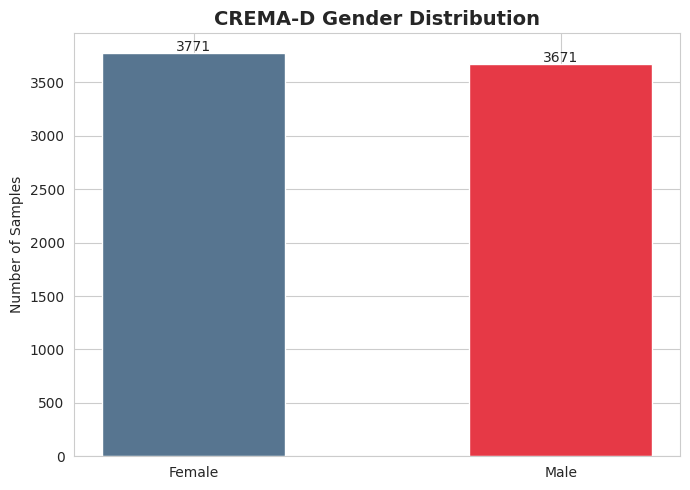

In [ ]:
gender_counts = df["gender"].value_counts()

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(
    gender_counts.index,
    gender_counts.values,
    color=["#577590", "#E63946"],
    edgecolor="white",
    width=0.5
)

ax.set_title("CREMA-D Gender Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Samples")

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 20,
        f"{int(h)}",
        ha="center"
    )

plt.tight_layout()

plt.show()